## Movie Genre Data Analysis

### Introduction
This project focuses on the movie genres using IMDB movie data from 1960 - 2015

### Research Questions:
1. Which genres are the most common (number of movies made)? Examine the trend over time. Are certain genres growing or declining across the 55 years?
2. Which genres have high avg. budget and revenue? Examine the avg spread - some genres might have high average but extreme variance (one blockbuster skewing the average)
2b. WHich generes have the high avg.profit?
4. Which genres have high avg. popularity? Cross examine with question 1. A genre can be popular but few movies made, or many movies but low popularity per film
5. Which genres have highest number of movies with a voting avg. >= 8? Check what % of each genre's total movies hit that threshold, not just raw count. A fair comparison
6. What is the avg. profit per year of each genre? Inflation matters — a $10M profit in 1960 is very different from 2015. Worth flagging if not adjusted.

### Research Hypotheses:
1. The best movies according to vote avg. return high profit and revenue.
2. The best movies according to popularity return high profit and revenue.
3. Highly budgeted movies return high revenue and profit.
4. Highly budgeted movies have a high popularity.

In [53]:
# importing libraries 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# reading in the file

movies = pd.read_csv(r'C:\Users\olatv\OneDrive\Pictures\Documents\Python\imdb_movies.csv')

In [55]:
# Creating a backup file for the original data

movies_raw = movies.copy()

In [56]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [57]:
# setting display options

pd.set_option('display.max.rows', 11000)
pd.set_option('display.max.columns', 25)

In [58]:
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.500000,2015,137999939.280026,1392445892.523800
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.100000,2015,137999939.280026,348161292.489031
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.300000,2015,101199955.472019,271619025.407628
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.500000,2015,183999919.040035,1902723129.801820
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.300000,2015,174799923.088033,1385748801.470520


### Data Cleaning

In [147]:
# Identifying and removing duplicates

movies.duplicated().head()

0    False
1    False
2    False
3    False
4    False
dtype: bool

In [60]:
movies[movies.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
2090,42194,tt0411951,0.596430,30000000,967000,TEKKEN,Jon Foo|Kelly Overton|Cary-Hiroyuki Tagawa|Ian...,NaN,Dwight H. Little,Survival is no game,martial arts|dystopia|based on video game|mart...,"In the year of 2039, after World Wars destroy ...",92,Crime|Drama|Action|Thriller|Science Fiction,Namco|Light Song Films,3/20/10,110,5.000000,2010,30000000.000000,967000.000000


In [61]:
# duplicate values identified on id 2090

# removing duplicates

movies.drop_duplicates(inplace = True)

# drop_duplicates() with default parameters:
# Considers all columns when identifying duplicates
# Keeps first occurrence, removes subsequent duplicates

In [62]:
# confirming removal of duplicates

movies[movies.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj


In [63]:
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.500000,2015,137999939.280026,1392445892.523800
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.100000,2015,137999939.280026,348161292.489031
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.300000,2015,101199955.472019,271619025.407628
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.500000,2015,183999919.040035,1902723129.801820
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.300000,2015,174799923.088033,1385748801.470520


In [64]:
# filtering out null values on the genres column

movies.dropna(subset = ['genres'], inplace = True)

In [65]:
movies.info()

# NULL entries removed, leaving the df with 10842 rows

<class 'pandas.core.frame.DataFrame'>
Index: 10842 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10842 non-null  int64  
 1   imdb_id               10834 non-null  object 
 2   popularity            10842 non-null  float64
 3   budget                10842 non-null  int64  
 4   revenue               10842 non-null  int64  
 5   original_title        10842 non-null  object 
 6   cast                  10767 non-null  object 
 7   homepage              2931 non-null   object 
 8   director              10800 non-null  object 
 9   tagline               8036 non-null   object 
 10  keywords              9367 non-null   object 
 11  overview              10839 non-null  object 
 12  runtime               10842 non-null  int64  
 13  genres                10842 non-null  object 
 14  production_companies  9826 non-null   object 
 15  release_date          10

In [66]:
# creating raw profit and profit adj columns
movies['profit'] = movies['revenue'] - movies['budget']

movies['profit_adj'] = movies['revenue_adj'] - movies['budget_adj']

In [67]:
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit,profit_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.500000,2015,137999939.280026,1392445892.523800,1363528810,1254445953.243774
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.100000,2015,137999939.280026,348161292.489031,228436354,210161353.209005
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.300000,2015,101199955.472019,271619025.407628,185238201,170419069.935609
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.500000,2015,183999919.040035,1902723129.801820,1868178225,1718723210.761785
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.300000,2015,174799923.088033,1385748801.470520,1316249360,1210948878.382487


In [68]:
# Selecting useful columns for the analysis for faster processing

movies_data = movies[['popularity', 'original_title', 'runtime', 'genres', 'vote_count', 'vote_average', 'release_year', 'budget_adj', 'revenue_adj', 'profit_adj']]

In [69]:
# Financial Analysis Methodology
# Using inflation-adjusted values (budget_adj, revenue_adj, profit_adj) throughout for fair cross-year comparison across the 55-year dataset.

In [70]:
movies_data = movies[['popularity', 'original_title', 'runtime', 'genres', 'vote_count', 'vote_average', 'release_year', 'budget_adj', 'revenue_adj', 'profit_adj']]

In [71]:
movies_cleaned = movies_data[(movies_data['budget_adj'] > 0) & (movies_data['revenue_adj'] > 0)]

In [72]:
# Zero values treated as missing data and excluded from financial analysis.

In [73]:
movies_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3854 entries, 0 to 10848
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   popularity      3854 non-null   float64
 1   original_title  3854 non-null   object 
 2   runtime         3854 non-null   int64  
 3   genres          3854 non-null   object 
 4   vote_count      3854 non-null   int64  
 5   vote_average    3854 non-null   float64
 6   release_year    3854 non-null   int64  
 7   budget_adj      3854 non-null   float64
 8   revenue_adj     3854 non-null   float64
 9   profit_adj      3854 non-null   float64
dtypes: float64(5), int64(3), object(2)
memory usage: 331.2+ KB


In [74]:
# Data reduction: 10,865 --> 3,854 rows after filtering zero financial values
# 5,674 rows (52%) excluded due to missing budget/revenue data
# Remaining 3,854 rows represent movies with complete financial records

In [75]:
movies_cleaned.head()

,popularity,original_title,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
0,32.985763,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
1,28.419936,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,6185,7.100000,2015,137999939.280026,348161292.489031,210161353.209005
2,13.112507,Insurgent,119,Adventure|Science Fiction|Thriller,2480,6.300000,2015,101199955.472019,271619025.407628,170419069.935609
3,11.173104,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,5292,7.500000,2015,183999919.040035,1902723129.801820,1718723210.761785
4,9.335014,Furious 7,137,Action|Crime|Thriller,2947,7.300000,2015,174799923.088033,1385748801.470520,1210948878.382487


In [76]:
# Splitting and exploding the genres column 

movies_cleaned['genres'] = movies_cleaned['genres'].str.split('|')
movies_exploded = movies_cleaned.explode('genres')
movies_exploded.head()

C:\Users\olatv\AppData\Local\Temp\ipykernel_13316\3421594551.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_cleaned['genres'] = movies_cleaned['genres'].str.split('|')


,popularity,original_title,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
0,32.985763,Jurassic World,124,Action,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
0,32.985763,Jurassic World,124,Adventure,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
0,32.985763,Jurassic World,124,Science Fiction,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
0,32.985763,Jurassic World,124,Thriller,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
1,28.419936,Mad Max: Fury Road,120,Action,6185,7.100000,2015,137999939.280026,348161292.489031,210161353.209005


In [77]:
movies_exploded.head()

,popularity,original_title,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
0,32.985763,Jurassic World,124,Action,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
0,32.985763,Jurassic World,124,Adventure,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
0,32.985763,Jurassic World,124,Science Fiction,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
0,32.985763,Jurassic World,124,Thriller,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
1,28.419936,Mad Max: Fury Road,120,Action,6185,7.100000,2015,137999939.280026,348161292.489031,210161353.209005


### Research Questions:
1. Which genres are the most common (number of movies made)? Examine the trend over time. Are certain genres growing or declining across the 55 years?
2. Which genres have high avg. budget and revenue? Examine the avg spread - some genres might have high average but extreme variance (one blockbuster skewing the average)
2b. WHich generes have the high avg.profit?
3. Which genres have high avg. popularity? Cross examine with question 1. A genre can be popular but few movies made, or many movies but low popularity per film
4. Which genres have highest number of movies with a voting avg. >= 8? Check what % of each genre's total movies hit that threshold, not just raw count. A fair comparison
5. What is the avg. profit per year of each genre? Inflation matters — a $10M profit in 1960 is very different from 2015. Worth flagging if not adjusted.

#### Q1

1. Which genres are the most common (number of movies made)? Examine the trend over time. Are certain genres growing or declining across the 55 years?

In [78]:
#1. Which genres are the most common (number of movies made)? Examine the trend over time. Are certain genres growing or declining across the 55 years?

common_genres = movies_exploded.groupby('genres')['release_year'].count().reset_index()
common_genres = common_genres.rename(columns = {'release_year': 'movie_count'})
common_genres.sort_values('movie_count', ascending = True, inplace = True)

In [79]:
common_genres

,genres,movie_count
16,TV Movie,1
9,Foreign,13
5,Documentary,35
19,Western,52
18,War,119
10,History,129
12,Music,136
2,Animation,201
13,Mystery,344
8,Fantasy,396


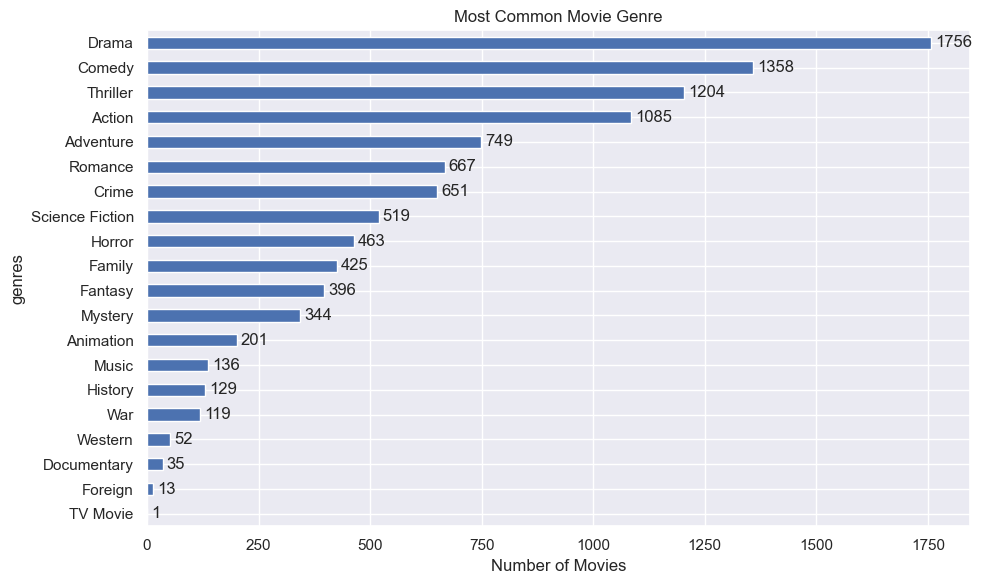

In [148]:
ax = common_genres.set_index('genres')['movie_count'].plot.barh(title = 'Most Common Movie Genre', figsize = (10, 6))

ax.bar_label(ax.containers[0], padding = 3)


plt.xlabel('Number of Movies')
plt.tight_layout()
plt.show()

In [81]:
# Genres Trend from 1960 - 2015

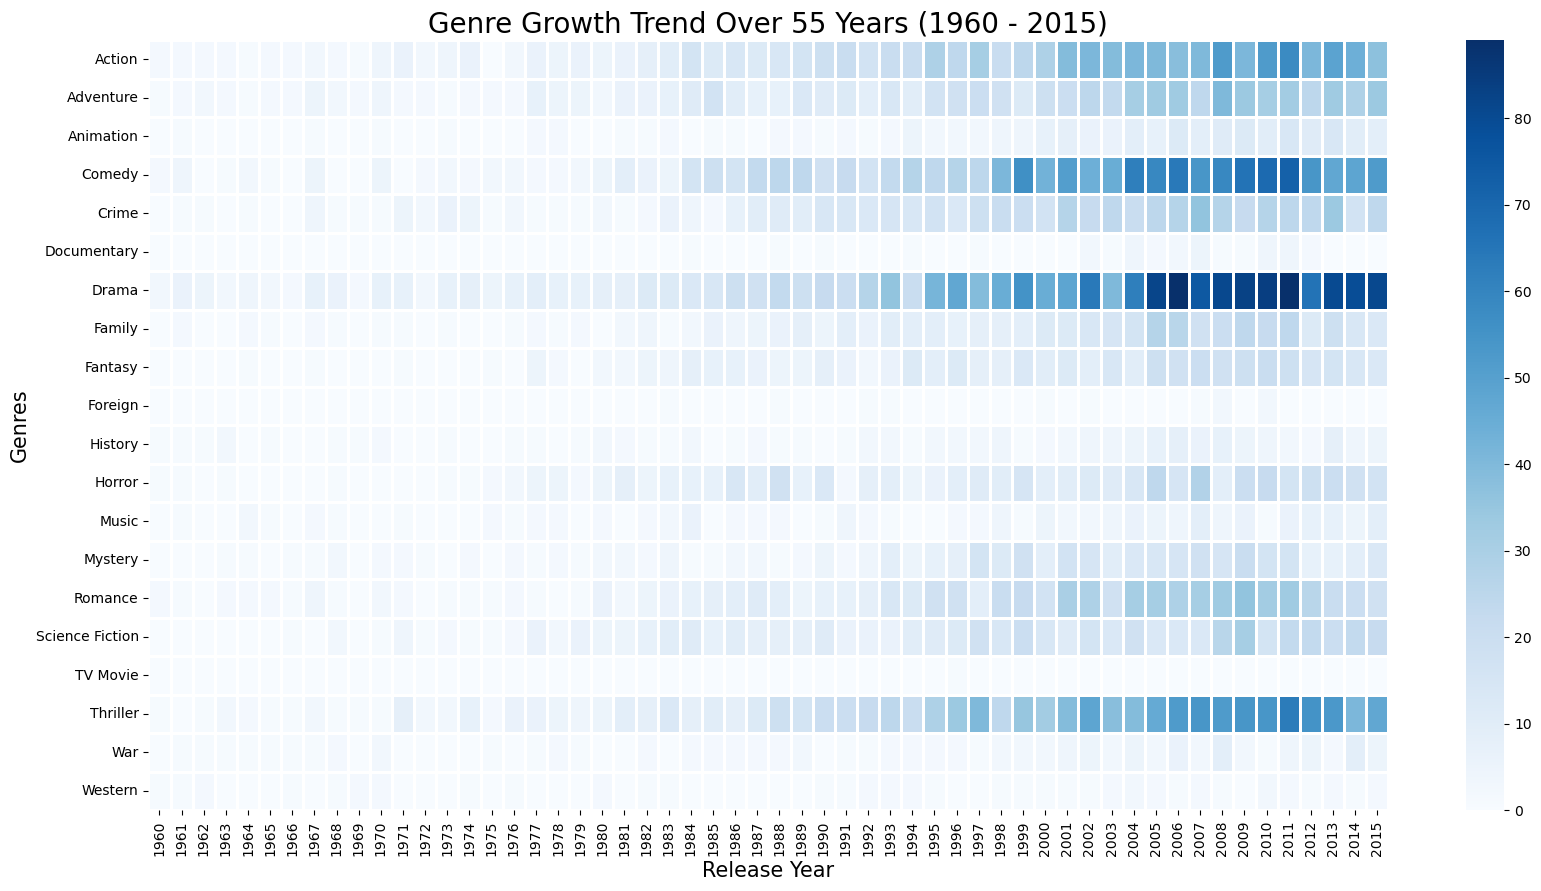

In [82]:
genre_trend = movies_exploded.groupby(['genres', 'release_year'])['original_title'].count().unstack().fillna(0)

plt.figure(figsize = (20, 10))

sns.heatmap(genre_trend, cmap = 'Blues', linewidths = 1)

plt.title('Genre Growth Trend Over 55 Years (1960 - 2015)', fontdict = {'fontsize': 20})
plt.xlabel('Release Year', fontdict = {'fontsize': 15})
plt.ylabel('Genres', fontdict = {'fontsize': 15})

plt.show()

#### Q1 Findings
1. Drama dominates with 1756 movies, followed by Comedy and Thriller with 1358 and 1204 movies respectively
2. Action is surprisingly the fourth with 1085 movies despite being considered the most common
3. NOTE - Counts reflect financially documented films only, not all IMDB movies

#### Genre Trend Analysis
1. Drama, Comedy, Action, and Thriller grew significantly with Drama recording the biggest rise. They rise became evident in the 1990s.
2. Despite these 4 genres being the most common genre, they all saw a decline in 2015 compared to certain periods in 2004 - 2007 and 2009 - 2011 where they performed much better.
3. Other niches, however, grew flat.
4. 4. The 2015 decline may reflect incomplete data collection 
   rather than a true industry downturn.

#### Q2

2. Which genres have high avg. budget and revenue? Examine the avg spread - some genres might have high average but extreme variance (one blockbuster skewing the average)

In [83]:
movies_financials = movies_exploded.groupby('genres')[['budget_adj', 'revenue_adj', 'profit_adj']].mean()

movies_financials.columns = ['avg_budget_adj', 'avg_revenue_adj', 'avg_profit_adj']

pd.options.display.float_format = '{:2f}'.format

movies_financials

,avg_budget_adj,avg_revenue_adj,avg_profit_adj
genres,,,
Action,66442622.970671,195387938.297204,128945315.326533
Adventure,81255726.529728,271407469.108229,190151742.578502
Animation,83472152.918087,290957382.263666,207485229.345579
Comedy,39176464.395770,121308528.538419,82132064.142649
Crime,39910067.931469,110395135.210048,70485067.278580
Documentary,5379701.627396,24806165.833207,19426464.205812
Drama,34712463.724213,101378466.610939,66666002.886727
Family,71100994.061481,243791030.515130,172690036.453649
Fantasy,80237516.214322,249992751.604266,169755235.389945


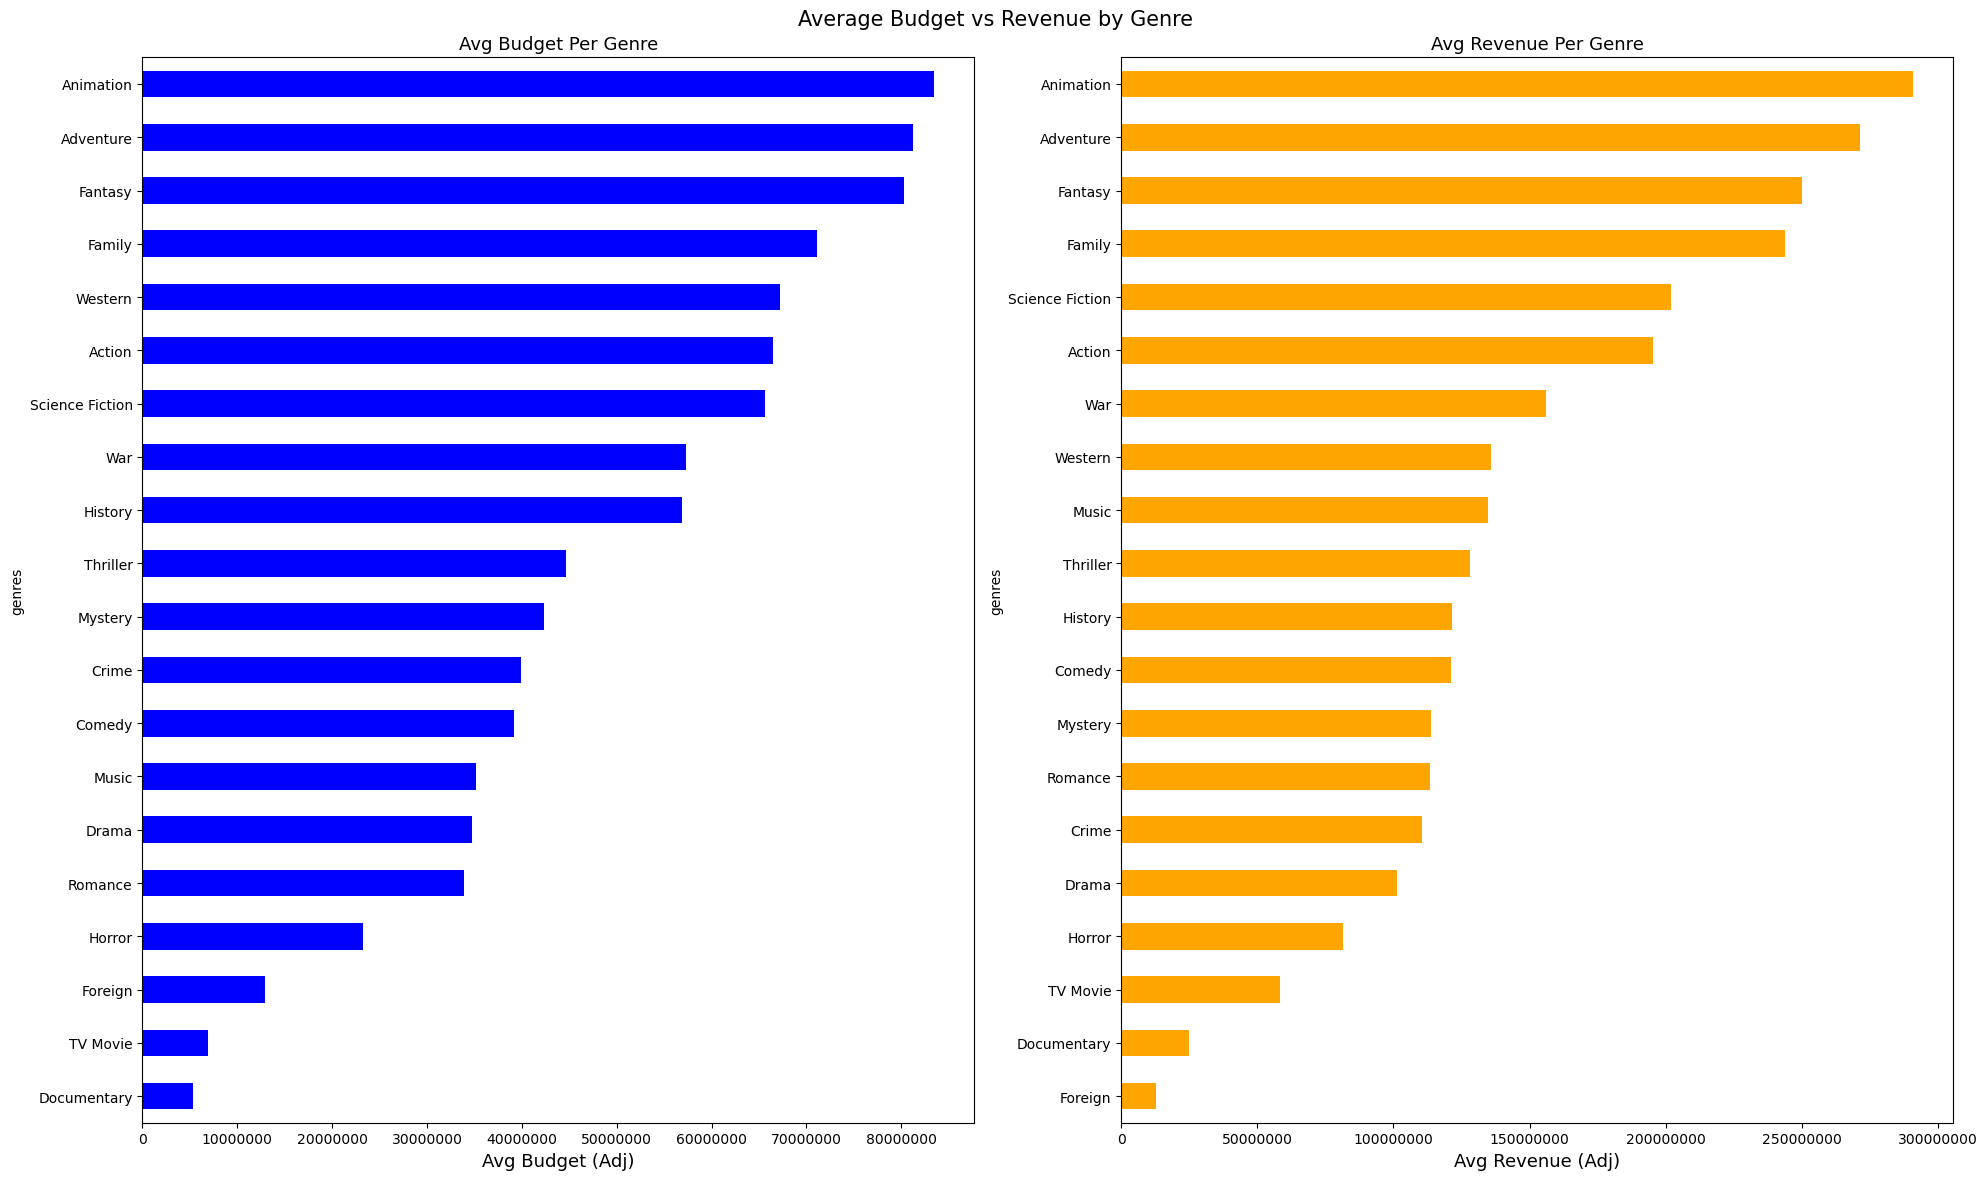

In [84]:
fig, axs = plt.subplots(1, 2, figsize = (20, 12))

movies_financials.sort_values(by = 'avg_budget_adj', ascending = True)['avg_budget_adj'].plot.barh(ax = axs[0], color = 'Blue')
axs[0].set_title('Avg Budget Per Genre', fontsize = 13)
axs[0].set_xlabel('Avg Budget (Adj)', fontdict = {'fontsize': 13})

movies_financials.sort_values(by = 'avg_revenue_adj', ascending = True)['avg_revenue_adj'].plot.barh(ax = axs[1], color = 'Orange')
axs[1].set_title('Avg Revenue Per Genre', fontsize = 13)
axs[1].set_xlabel('Avg Revenue (Adj)', fontdict = {'fontsize': 13})

axs[0].ticklabel_format(style = 'plain', axis = 'x')
axs[1].ticklabel_format(style = 'plain', axis = 'x')

plt.suptitle('Average Budget vs Revenue by Genre', fontsize=15)
plt.tight_layout()
plt.show()

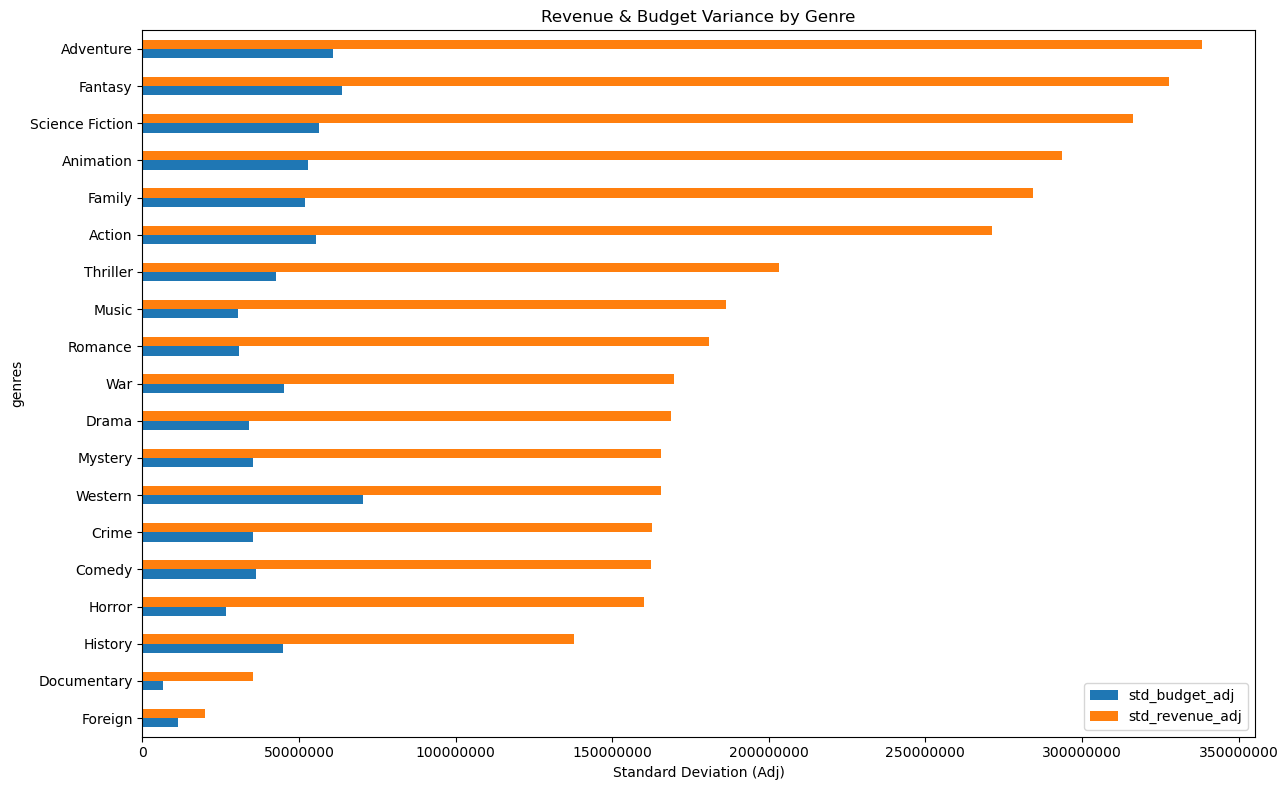

In [85]:
# VARIANCE Analysis

movies_variance = movies_exploded.groupby('genres')[['budget_adj', 'revenue_adj']].std()
movies_variance.columns = ['std_budget_adj', 'std_revenue_adj']
movies_variance.dropna().sort_values('std_revenue_adj', ascending = True)[['std_budget_adj', 'std_revenue_adj']].plot.barh(figsize = (13, 8), 
title = 'Revenue & Budget Variance by Genre')

# TV Movie excluded from variance analysis — insufficient sample size (n=1... from the count chart in Q1)
# Standard deviation requires minimum 2 data points

plt.xlabel('Standard Deviation (Adj)')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

#### Q2 Findings:

1. Animation, Adventure, Fantasy and Family genres have the highest budget for production with Animation being the highest. 
2. These same genres earn the highest avg revenue in the same order as the budget.
3. These insights show a high-risk to a high-reward pattern. 
4. An important finidng is that while Science Fiction is the seventh highest genre on cost production, it moved to being the fifth highest genre by
revenue. That genre could potentially attract investment.
5. On the low end, Foreign genre performed poorly as the avg budget is higher than the avg revenue, leading to a loss rather than a profit.

#### Variance Analysis Findings:
1. Most of the genres have a higher standard deviation than their average revenue and this means that the averages can not be totally relied upon.
2. Adventure, for instance, has an average revenue of 290M while its standard deviation is around 330M, a gap of 40M
3. The average for this genre could potentially have a few outliers that pulled up the high averages rather than an equal distribution across the data, meaning that a few popular series could have significantly pulled up the high average.
4. This pattern is seen across almost the entire genres.
5. Median revenue would be a more reliable measure of typical genre performance than the mean, as it is not affected by outlier blockbuster films.

<Figure size 2000x1000 with 0 Axes>

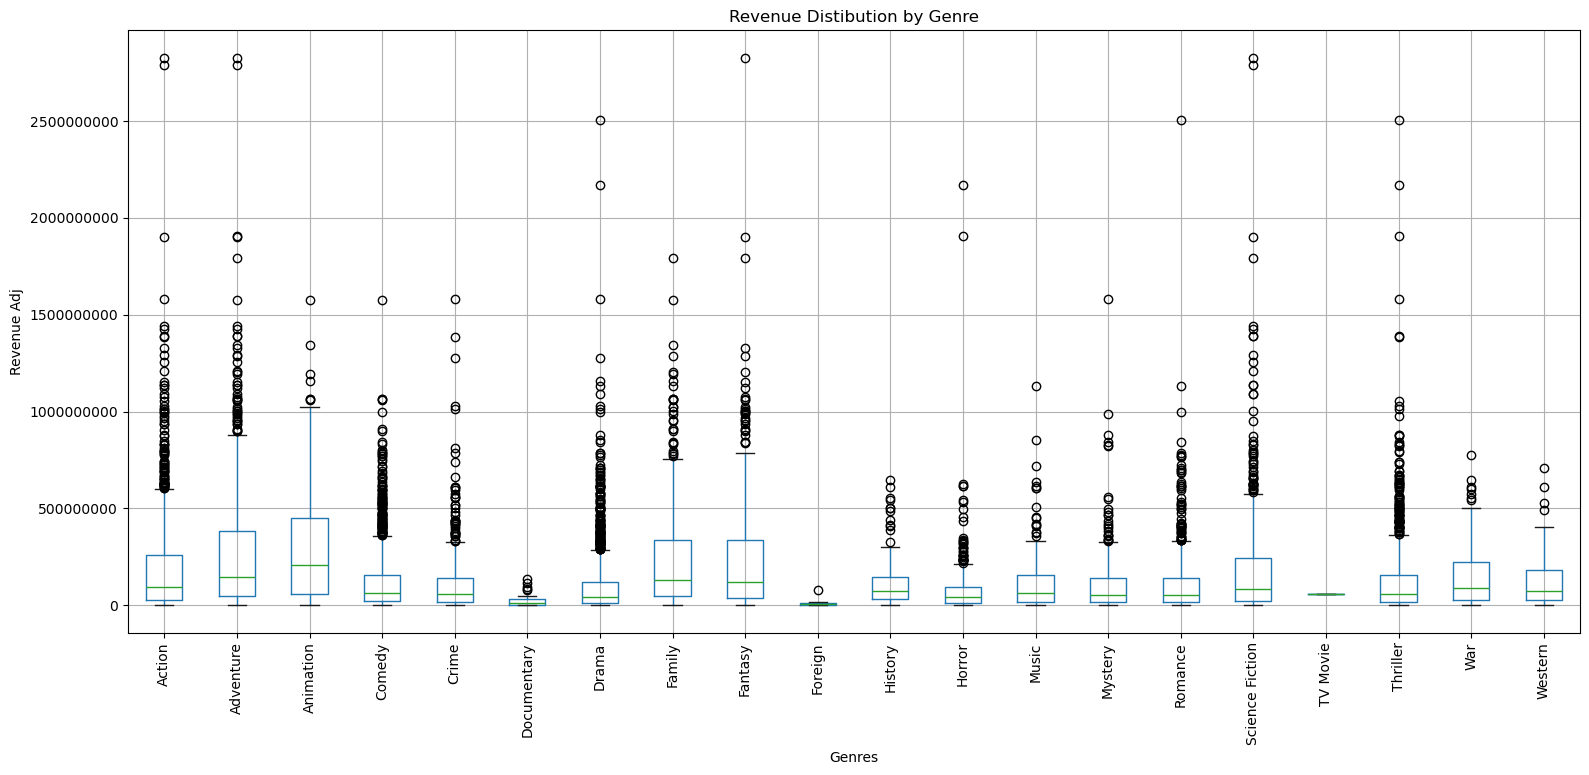

In [157]:
plt.figure(figsize = (20, 10))

movies_exploded.boxplot(column = 'revenue_adj', by = 'genres', figsize = (16, 8), rot = 90)

plt.title('Revenue Distibution by Genre')
plt.suptitle('')
plt.ylabel('Revenue Adj')
plt.xlabel('Genres')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.tight_layout()

plt.show()

1. Animation's high average is partly a sample size issue (only 201 films) combined with a few massive Pixar/Disney blockbusters. A genre with 201 films where 10 earn billions will have a severely skewed average.
2. The median revenue across most genres sits between 10M-50M, significantly lower than the averages suggested, confirming that typical film performance is enhanced by a few percentage of Blockbuster outliers.Those outliers are implying through the average that Animation films generally perform at a high level when in reality most Animation films earn 10M-50M.

#### Q3

3.Which genres have high avg. popularity? Cross examine with question 1. A genre can be popular but few movies made, or many movies but low popularity per film

In [87]:
avg_pop = movies_exploded.groupby('genres')['popularity'].mean().reset_index()
avg_pop.columns = ['genres', 'avg_popularity']
avg_pop.set_index('genres').sort_values('avg_popularity', ascending = True)

,avg_popularity
genres,
Foreign,0.179608
TV Movie,0.273628
Documentary,0.294458
Horror,0.854005
Music,0.899005
Romance,0.954889
History,0.970674
Drama,1.001411
Comedy,1.012321


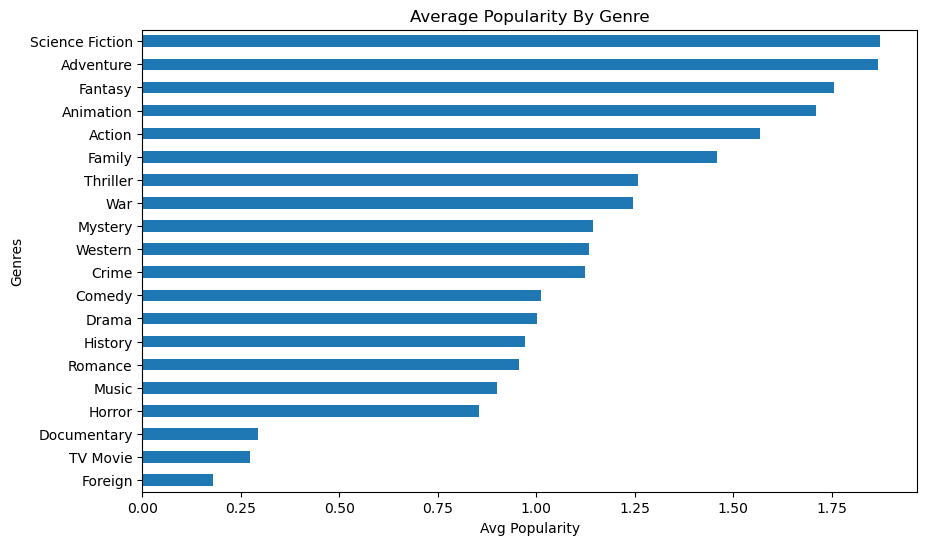

In [88]:
avg_popularity = avg_pop.set_index('genres').sort_values('avg_popularity', ascending = True)

avg_popularity.plot.barh(title = 'Average Popularity By Genre', figsize = (10, 6), legend = False)

plt.xlabel('Avg Popularity')
plt.ylabel('Genres')

plt.show()

#### Q3 Findings:
1. Science Fiction, Adventure, Fantasy, Animation, Action are the top 5 popular movies with Science Fiction being the most popular.
2. Cross examination with Question 1 - quantity of production and popularity are not correlated. Drama, Comedy and Thriller dominate production (with over 1000 movies each), yet they rank low in popularity. Science Fiction tops popularity with only 519 movies, followed by Adventure, Fantasy, Animation, Action with fewer than 750 movies. Producing more movies does not drive popularity.
3. The analysis also shows that the most popular movies are also the top earning movies by revenue, shows a relationship between movie popularity and commercial success.

#### Q4

Which genres have highest number of movies with a voting avg. >= 8? Check what % of each genre's total movies hit that threshold, not just raw count. A fair comparison

In [89]:
# filtering movies exploded df to vote_count > 50 and voting_avg >= 8
# vote_count > 50 ensures the rating is reliable. A movie with 2 votes and an 8.0 average is not the same as a movie with 5,000 votes 
#and an 8.0 average. Setting a minimum vote threshold removes statistically insignificant ratings.
#vote_average >= 8 is the actual quality filter - only movies rated 8 or above qualify as "best movies.

vote = movies_exploded[(movies_exploded['vote_count'] > 50) & (movies_exploded['vote_average'] >= 8)]

vote_filtered = vote.groupby('genres')['vote_average'].count().reset_index()
vote_filtered.columns = ['genres', 'movie_count']
vote_filtered.sort_values('movie_count', ascending = True)

,genres,movie_count
2,Animation,1
6,Family,1
7,Fantasy,1
9,Horror,1
10,Music,1
11,Romance,1
0,Action,2
1,Adventure,2
3,Comedy,2
8,History,2


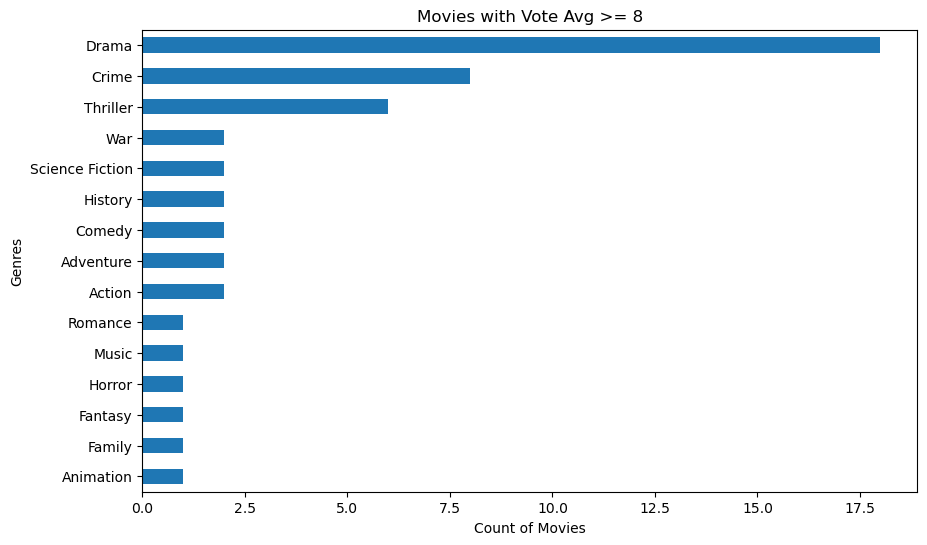

In [162]:
vote_viz = vote_filtered.sort_values('movie_count', ascending = True)
vote_viz.set_index('genres')['movie_count'].plot.barh(title = 'Movies with Vote Avg >= 8', figsize = (10, 6), legend = False)

plt.xlabel('Count of Movies')
plt.ylabel('Genres')
plt.show()

In [91]:
vote_filtered['rating percentage'] = (vote_filtered['movie_count'] / common_genres['movie_count']) * 100

In [92]:
common_genres

,genres,movie_count
16,TV Movie,1
9,Foreign,13
5,Documentary,35
19,Western,52
18,War,119
10,History,129
12,Music,136
2,Animation,201
13,Mystery,344
8,Fantasy,396


In [93]:
hit_rate = vote_filtered.merge(common_genres, on = 'genres', suffixes = ('_rated', '_total'))
hit_rate['rating percentage'] = hit_rate['movie_count_rated']/hit_rate['movie_count_total'] * 100
hit_rate.sort_values('rating percentage', ascending = False)

,genres,movie_count_rated,rating percentage,movie_count_total
14,War,2,1.680672,119
8,History,2,1.550388,129
4,Crime,8,1.228879,651
5,Drama,18,1.025057,1756
10,Music,1,0.735294,136
13,Thriller,6,0.498339,1204
2,Animation,1,0.497512,201
12,Science Fiction,2,0.385356,519
1,Adventure,2,0.267023,749
7,Fantasy,1,0.252525,396


#### Q4 Findings:
1. Drama dominates with 18 highly rated movies, followed by Crime (8) and Thriller (6). The top 3 are completely different from Q2 and Q3 top genres
2. The genres with the highest commercial success in revenue and popularity are not the highly rated. Drama produces the highly rated movies but performs low in popularity and revenue generation. High rating is not a potential driver of revenue generation and popularity.

### Hit Rate Analysis
1. Raw counts favours Drama 
2. 2. However, War tops the hit rate at 1.68%, followed by History (1.55%), Crime (1.23%) and Drama (1.03%). Despite these genres not being the most popular or commercially successful, they consistently produce a higher proportion of critically acclaimed films, suggesting quality and commercial success operate independently in the film industry.
3. Comedy and Action were rated poorly despite being the most produced genres.

#### Q5
What is the avg. profit per year of each genre? Inflation matters — a $10M profit in 1960 is very different from 2015. Worth flagging if not adjusted.

In [94]:
yearly_profit = pd.DataFrame(movies_exploded.groupby(['release_year', 'genres'])['profit_adj'].mean())
yearly_profit.columns = ['avg_profit_adj']
yearly_profit

pd.pivot_table(yearly_profit, values = 'avg_profit_adj', columns = 'release_year', index = 'genres')

release_year,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
genres,,,,,,,,,,,,,,,,,,,,,,,,,
Action,187660454.204287,77325528.804489,336994985.082115,247065827.482326,853474463.608172,534771534.891060,31396641.664455,331478210.678587,157040274.956743,445668194.738850,155706859.270658,241500489.424464,...,92866585.295348,66528235.987438,84872836.155718,110790149.551479,93799150.145805,159525883.308871,75347152.230769,105091437.918813,168877398.321477,113649570.622398,192857914.483227,243585035.873395
Adventure,21418470.463155,856343808.267703,356818219.498710,275546544.968560,853474463.608172,534771534.891060,49998824.347429,451001552.481386,178896990.479533,206173971.374801,88792348.821405,314822851.320692,...,155919799.828999,131142501.934589,114069745.922437,215920003.225467,89717880.611294,251100422.311989,194280077.064516,214670650.014104,313066750.231500,193856399.209035,256894302.959742,264127108.226425
Animation,NaN,1545635294.872877,NaN,NaN,NaN,NaN,NaN,1319404004.029252,NaN,NaN,290227277.577772,NaN,...,257533525.479226,170354079.605635,124065849.061794,258818612.888636,162266105.029215,208487432.005352,298070375.400000,202280450.315857,245342456.202758,267659928.586004,214204893.940971,301818946.532996
Comedy,96217225.316410,404828348.268345,NaN,67460766.031618,244685054.565420,168515725.942909,NaN,226575326.723793,NaN,NaN,154582521.861714,NaN,...,58025728.979389,59369489.881994,60185810.125175,82347092.227708,58271306.148625,75418931.876734,58990259.275362,62294876.612863,78273597.636614,87534475.721545,94144489.365543,93269236.218459
Crime,NaN,274701290.023256,80228925.919492,NaN,34201119.077966,NaN,NaN,153283434.402595,230703333.834850,572485481.134689,-47739130.923162,97346196.409906,...,45092019.633400,32052412.999342,43046399.516579,28888153.188289,74517806.882114,24725143.146603,26283368.000000,50091861.089138,68838114.029464,51976546.583131,27226907.041811,121022188.243570
Documentary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41951292.101469,4115772.874502,38832134.068710,22767530.447646,4253703.861999,-2605533.365275,1169729.000000,25590346.685822,24516203.112312,NaN,NaN,NaN
Drama,248697693.096788,104685117.315958,149330004.952204,48974967.110705,134462847.145817,564570810.861683,115001289.858820,273480937.816420,95038496.660732,408650158.652411,317013499.342484,105533995.543059,...,55414412.568577,42092113.105367,29909248.832677,42461077.209406,49818346.514339,43027436.581064,41015383.011905,27046964.949791,77489830.037505,37950124.937052,44952708.573752,47618965.221482
Family,NaN,776465078.040424,NaN,NaN,531743861.346254,1072786239.704787,NaN,630286565.185584,42628952.581559,NaN,290227277.577772,5385194.914437,...,199786511.442632,126781302.358676,86673218.627977,214357974.676078,124955987.432533,163212854.985474,250423572.045455,189635692.823934,229259124.351601,213511863.582302,162640687.512887,246035297.270623
Fantasy,NaN,NaN,NaN,NaN,676823015.127026,NaN,NaN,-58830873.658084,NaN,NaN,NaN,5385194.914437,...,272236984.667118,138074468.741978,116441665.480135,238554949.578275,129933542.741599,259483291.280924,176300240.571429,222814577.828173,258424142.246367,184119640.858043,267911997.974126,202110329.889916


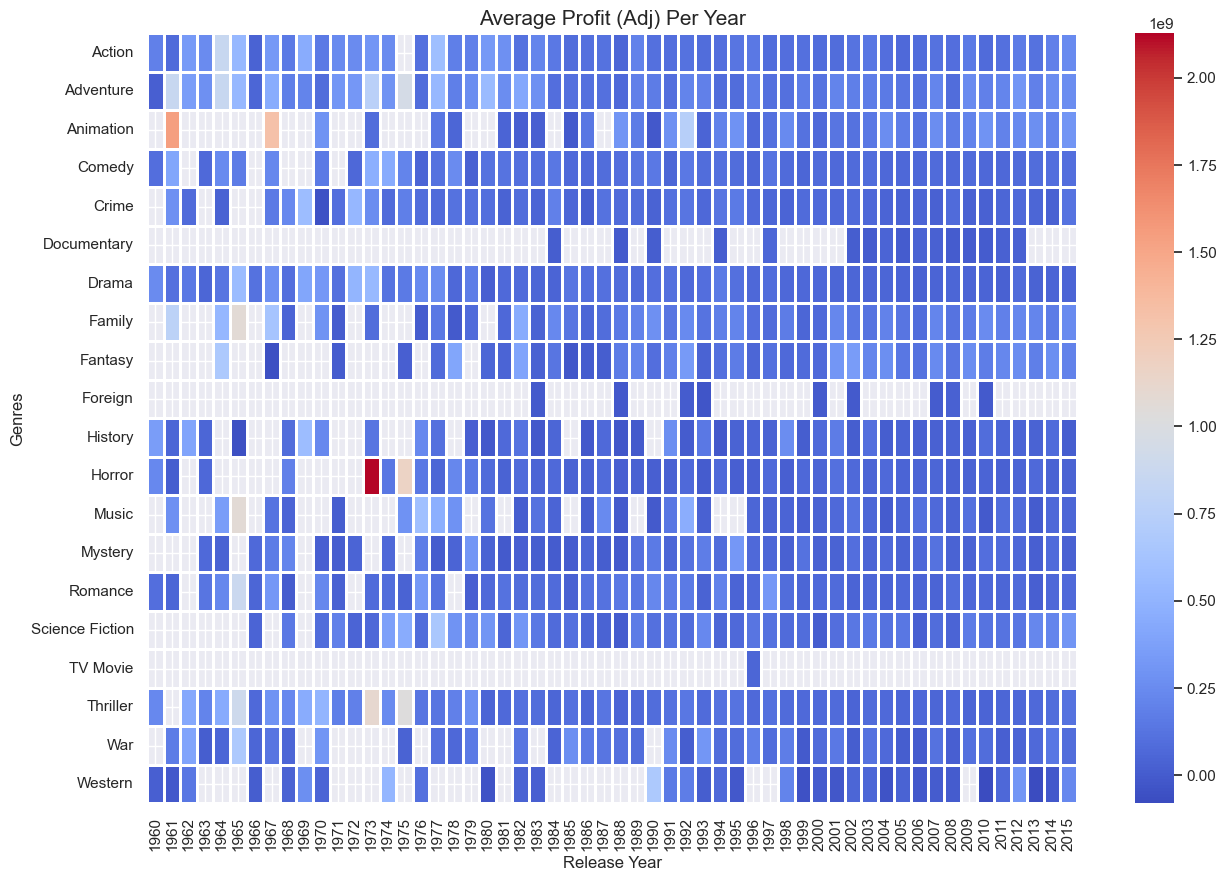

In [95]:
year_profit = pd.pivot_table(yearly_profit, values = 'avg_profit_adj', columns = 'release_year', index = 'genres')

sns.set(rc = {'figure.figsize': (15, 10)})
sns.heatmap(year_profit, cmap = 'coolwarm', linewidths = 1)

plt.title('Average Profit (Adj) Per Year', fontdict = {'fontsize': 15})
plt.xlabel('Release Year')
plt.ylabel('Genres')

plt.show()

#### Q5 Finding: 
1. Early decades show sporadic high-profit years driven by individual blockbusters in small genre pools. Later decades show more consistent but moderate profits as genre output increased and averaged across more films.
2. The red Horror cell likely represents a single high-profit outlier film rather than genre-wide performance consistent with the variance findings from Q2

### Research Hypotheses

1. The best movies according to vote avg. return high profit and revenue.
2. The best movies according to popularity return high profit and revenue.
3. Highly budgeted movies return high revenue and profit.
4. Highly budgeted movies have a high popularity.

In [96]:
movies_df = movies[['popularity', 'original_title', 'runtime', 'genres', 'vote_count', 'vote_average', 'release_year', 'budget_adj', 'revenue_adj', 'profit_adj']]

movies_df.head()

,popularity,original_title,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
0,32.985763,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,5562,6.500000,2015,137999939.280026,1392445892.523800,1254445953.243774
1,28.419936,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,6185,7.100000,2015,137999939.280026,348161292.489031,210161353.209005
2,13.112507,Insurgent,119,Adventure|Science Fiction|Thriller,2480,6.300000,2015,101199955.472019,271619025.407628,170419069.935609
3,11.173104,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,5292,7.500000,2015,183999919.040035,1902723129.801820,1718723210.761785
4,9.335014,Furious 7,137,Action|Crime|Thriller,2947,7.300000,2015,174799923.088033,1385748801.470520,1210948878.382487


In [97]:
# The best movies according to vote avg. return high profit and revenue.

movies_counted = movies_df[movies_df['vote_count']>= 50]

movies_counted.corr(method = 'spearman', numeric_only = True)

,popularity,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
popularity,1.000000,0.230214,0.768888,0.189226,0.070895,0.474902,0.566850,0.481102
runtime,0.230214,1.000000,0.263164,0.286082,-0.131512,0.389638,0.353626,0.218754
vote_count,0.768888,0.263164,1.000000,0.285084,0.149045,0.532098,0.647573,0.557752
vote_average,0.189226,0.286082,0.285084,1.000000,-0.153545,-0.008679,0.143677,0.215094
release_year,0.070895,-0.131512,0.149045,-0.153545,1.000000,-0.146914,-0.215527,-0.164395
budget_adj,0.474902,0.389638,0.532098,-0.008679,-0.146914,1.000000,0.705050,0.338472
revenue_adj,0.566850,0.353626,0.647573,0.143677,-0.215527,0.705050,1.000000,0.850694
profit_adj,0.481102,0.218754,0.557752,0.215094,-0.164395,0.338472,0.850694,1.000000


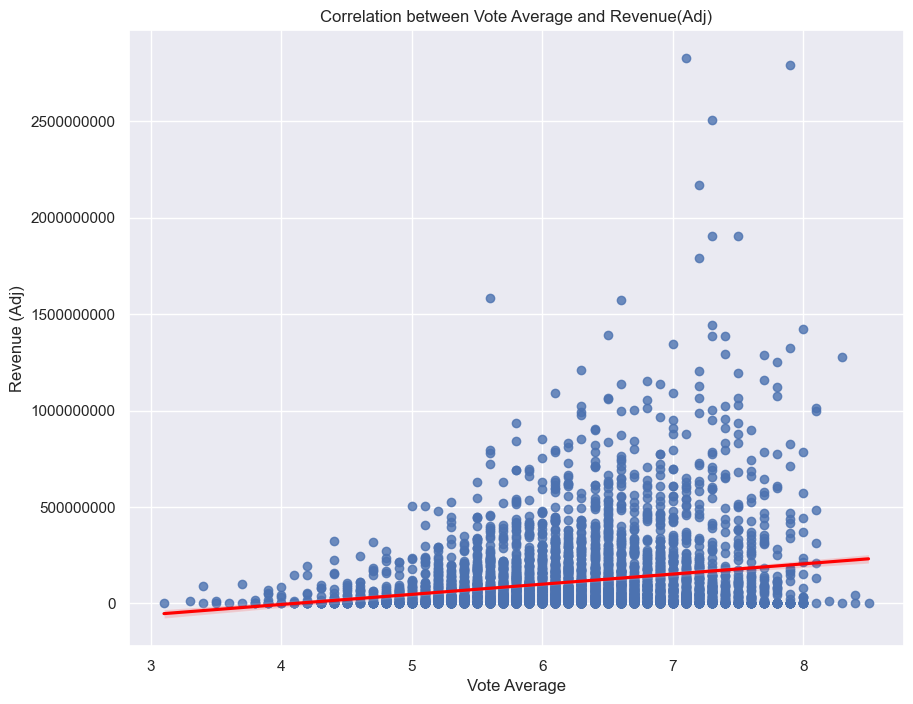

In [139]:
plt.figure(figsize=(10, 8))

sns.regplot(data = movies_counted, x = 'vote_average', y = 'revenue_adj', line_kws = {'color': 'red'})

plt.title('Correlation between Vote Average and Revenue(Adj)')
plt.xlabel('Vote Average')
plt.ylabel('Revenue (Adj)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

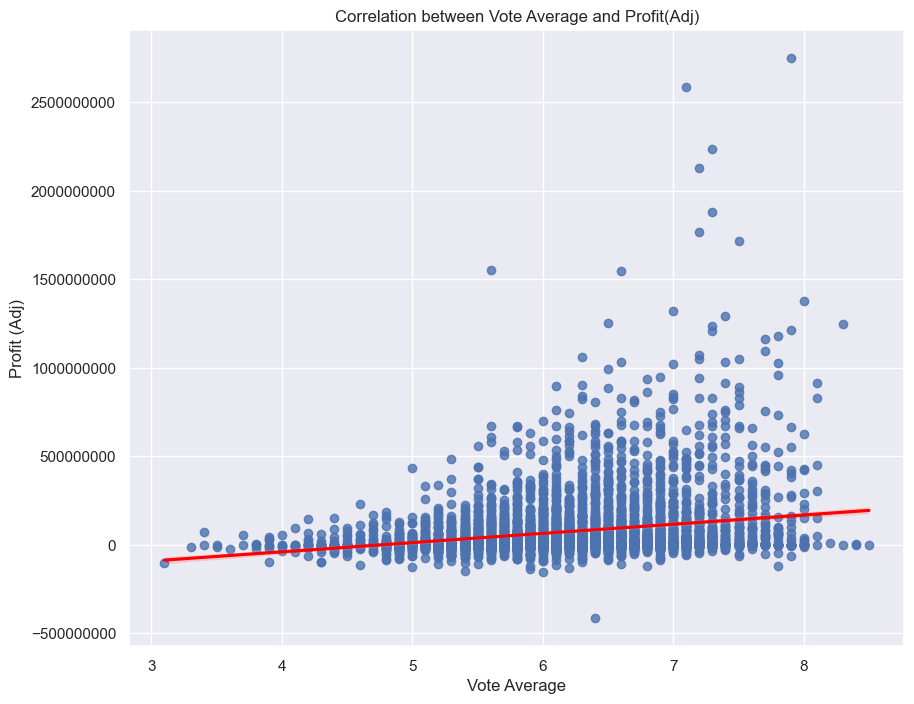

In [138]:
plt.figure(figsize=(10, 8))

sns.regplot(data = movies_counted, x = 'vote_average', y = 'profit_adj', line_kws = {'color': 'red'})

plt.title('Correlation between Vote Average and Profit(Adj)')
plt.xlabel('Vote Average')
plt.ylabel('Profit (Adj)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

#### Hypothesis 1 Findings
1. The hypothesis that the best movies according to vote avg. return high profit and revenue is statistically not true. 
2. The analysis show a weak correlation between vote avg and both revenue_adj and profit_adj.
3. High rating do not drive commercial success. This is consistent with the Q4 findings.

In [100]:
# The best movies according to popularity return high profit and revenue.

movies_counted.corr(method = 'spearman', numeric_only = True)

,popularity,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
popularity,1.000000,0.230214,0.768888,0.189226,0.070895,0.474902,0.566850,0.481102
runtime,0.230214,1.000000,0.263164,0.286082,-0.131512,0.389638,0.353626,0.218754
vote_count,0.768888,0.263164,1.000000,0.285084,0.149045,0.532098,0.647573,0.557752
vote_average,0.189226,0.286082,0.285084,1.000000,-0.153545,-0.008679,0.143677,0.215094
release_year,0.070895,-0.131512,0.149045,-0.153545,1.000000,-0.146914,-0.215527,-0.164395
budget_adj,0.474902,0.389638,0.532098,-0.008679,-0.146914,1.000000,0.705050,0.338472
revenue_adj,0.566850,0.353626,0.647573,0.143677,-0.215527,0.705050,1.000000,0.850694
profit_adj,0.481102,0.218754,0.557752,0.215094,-0.164395,0.338472,0.850694,1.000000


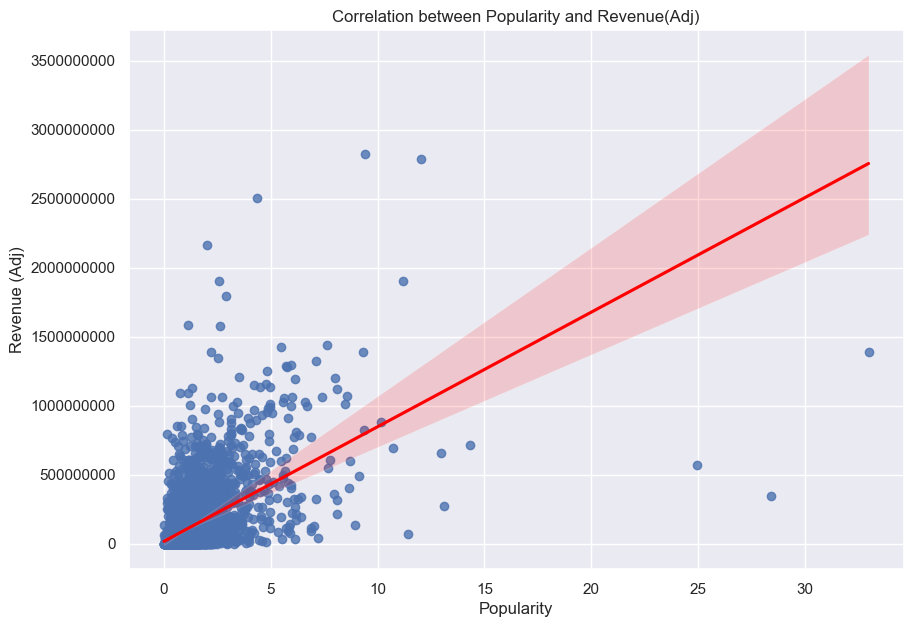

In [143]:
plt.figure(figsize=(10, 7))

sns.regplot(data = movies_counted, x = 'popularity', y = 'revenue_adj', line_kws = {'color': 'red'})

plt.title('Correlation between Popularity and Revenue(Adj)')
plt.xlabel('Popularity')
plt.ylabel('Revenue (Adj)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

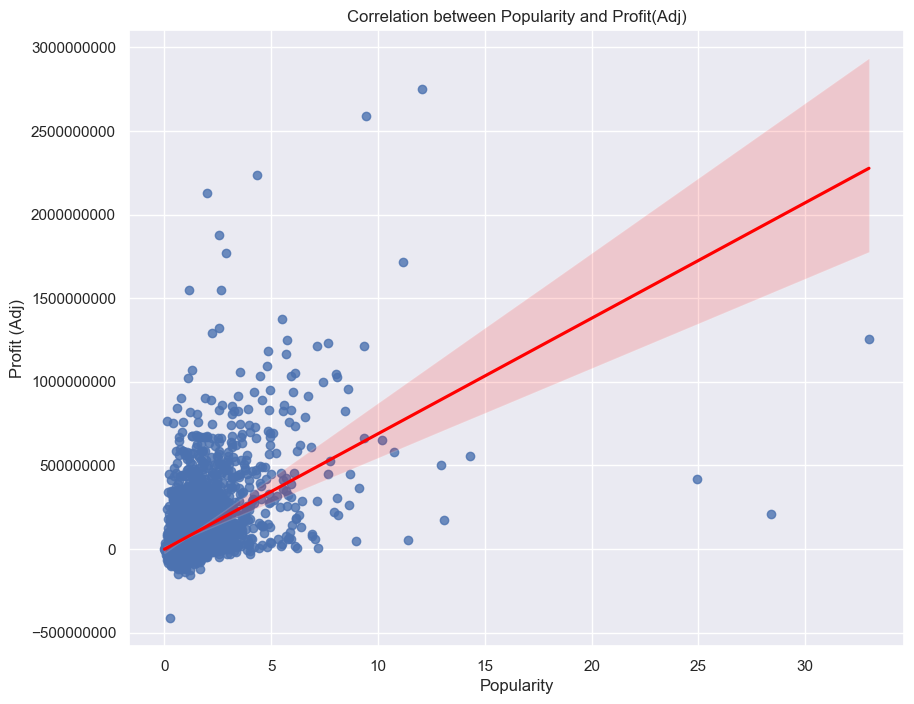

In [142]:
plt.figure(figsize=(10, 8))

sns.regplot(data = movies_counted, x = 'popularity', y = 'profit_adj', line_kws = {'color': 'red'})

plt.title('Correlation between Popularity and Profit(Adj)')
plt.xlabel('Popularity')
plt.ylabel('Profit (Adj)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

#### Hypothesis 2 Findings
1. There is a clear positive correlation between Popularity and both Revenue Adj and Profit Adj.
2. Popular films tend to generate more higher commerical returns. This is consistent with Q3 findings where the most popular genres topped the revenue charts in Q2 analysis.
3. The hypothesis that the best movies according to popularity return high profit and revenue is statistically correct.

In [103]:
# Highly budgeted movies return high revenue and profit.

movies_counted.corr(method = 'spearman', numeric_only = True)

,popularity,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
popularity,1.000000,0.230214,0.768888,0.189226,0.070895,0.474902,0.566850,0.481102
runtime,0.230214,1.000000,0.263164,0.286082,-0.131512,0.389638,0.353626,0.218754
vote_count,0.768888,0.263164,1.000000,0.285084,0.149045,0.532098,0.647573,0.557752
vote_average,0.189226,0.286082,0.285084,1.000000,-0.153545,-0.008679,0.143677,0.215094
release_year,0.070895,-0.131512,0.149045,-0.153545,1.000000,-0.146914,-0.215527,-0.164395
budget_adj,0.474902,0.389638,0.532098,-0.008679,-0.146914,1.000000,0.705050,0.338472
revenue_adj,0.566850,0.353626,0.647573,0.143677,-0.215527,0.705050,1.000000,0.850694
profit_adj,0.481102,0.218754,0.557752,0.215094,-0.164395,0.338472,0.850694,1.000000


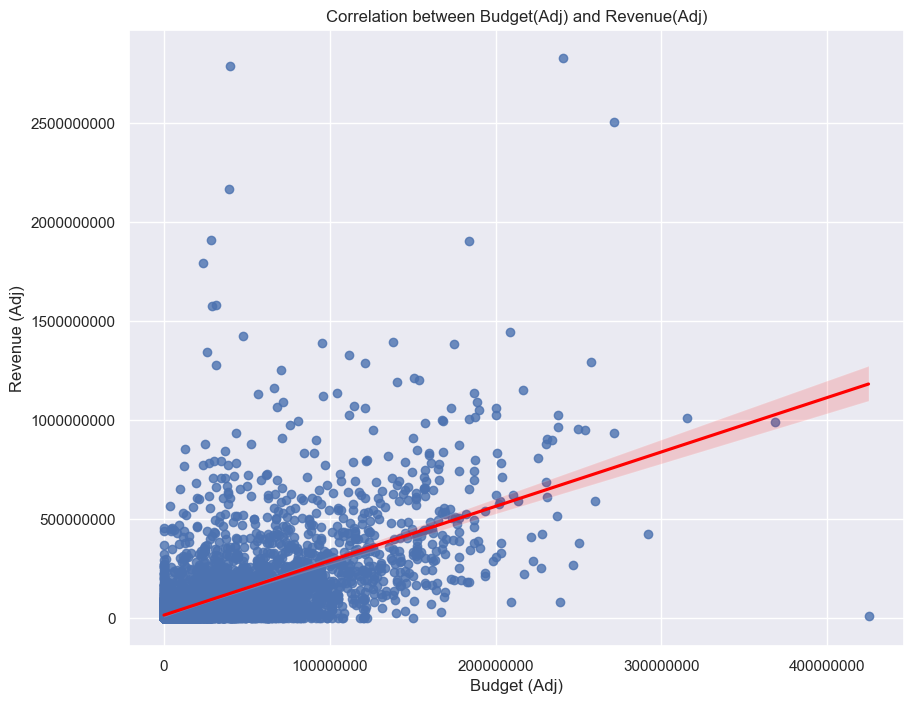

In [144]:
plt.figure(figsize=(10, 8))

sns.regplot(data = movies_counted, x = 'budget_adj', y = 'revenue_adj', line_kws = {'color': 'red'})
plt.title('Correlation between Budget(Adj) and Revenue(Adj)')
plt.xlabel('Budget (Adj)')
plt.ylabel('Revenue (Adj)')
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

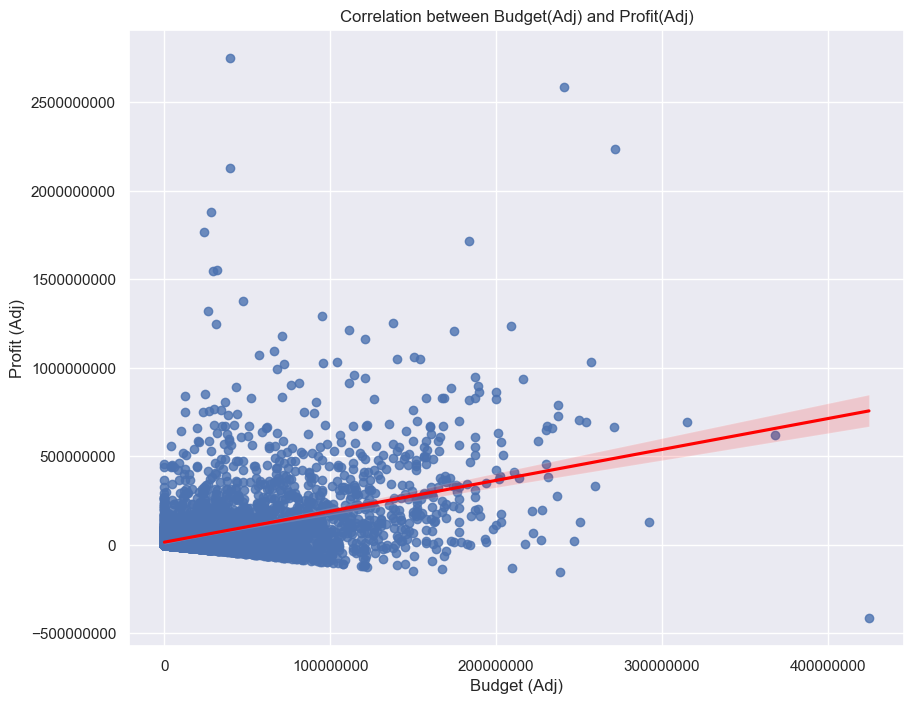

In [145]:
plt.figure(figsize=(10, 8))

sns.regplot(data = movies_counted, x = 'budget_adj', y = 'profit_adj', line_kws = {'color': 'red'})
plt.title('Correlation between Budget(Adj) and Profit(Adj)')
plt.xlabel('Budget (Adj)')
plt.ylabel('Profit (Adj)')
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

#### Hypothesis 3 Findings
1. There isn't a very strong correlation between budget and both revenue_adj and profit_adj. Numerically, the correlation between Budget and Revenue_Adj is 0.7 while with Profit is 0.3. The Revenue correlation is a strong one but what this means is that even though revenue grows with the budget, the costs grow proportionally too, eating into the profit margin.
2. Big budgets buy big revenues but don't necessarily buy proportionally bigger profits. The hypothesis is partially supported because budget drives revenue strongly, but profit less so.

In [106]:
# Highly budgeted movies have a high popularity.

movies_counted.corr(method = 'spearman', numeric_only = True)

,popularity,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
popularity,1.000000,0.230214,0.768888,0.189226,0.070895,0.474902,0.566850,0.481102
runtime,0.230214,1.000000,0.263164,0.286082,-0.131512,0.389638,0.353626,0.218754
vote_count,0.768888,0.263164,1.000000,0.285084,0.149045,0.532098,0.647573,0.557752
vote_average,0.189226,0.286082,0.285084,1.000000,-0.153545,-0.008679,0.143677,0.215094
release_year,0.070895,-0.131512,0.149045,-0.153545,1.000000,-0.146914,-0.215527,-0.164395
budget_adj,0.474902,0.389638,0.532098,-0.008679,-0.146914,1.000000,0.705050,0.338472
revenue_adj,0.566850,0.353626,0.647573,0.143677,-0.215527,0.705050,1.000000,0.850694
profit_adj,0.481102,0.218754,0.557752,0.215094,-0.164395,0.338472,0.850694,1.000000


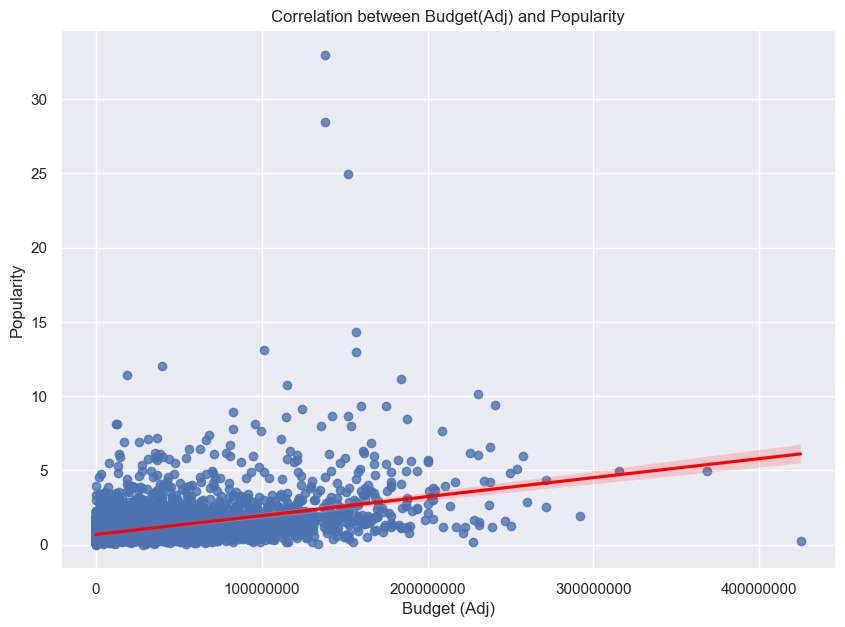

In [146]:
plt.figure(figsize=(10, 7))

sns.regplot(data = movies_counted, x = 'budget_adj', y = 'popularity', line_kws = {'color': 'red'})

plt.title('Correlation between Budget(Adj) and Popularity')
plt.xlabel('Budget (Adj)')
plt.ylabel('Popularity')
plt.ticklabel_format(style='plain', axis='x')

plt.show()

#### Hypothesis 4 Findings
1. There is a weak positive correlation between Budget and Popularity. Production budget alone is insufficient to predict audience popularity.A high production budget does not guarantee audience engagement suggesting marketing and promotion are stronger popularity drivers.
2. If popularity drives commercial success, then, marketing spend, distribution strategy and word of mouth could potentially play a more significant role in driving popularity which could yield more commercial returns.
3. Higher Budget on movies production does not guarantee popularity.